## CMSE 402 ICA 19
## Mikel Good
## 3/26/2026

In [1]:
import pandas as pd
from pandas.plotting import parallel_coordinates, scatter_matrix
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

In [2]:
pen = pd.read_csv("data_files/penguins.csv")
pen.head(5)

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Chinstrap,46.7,17.9,195.0,3300.0
1,Adelie,35.9,16.6,190.0,3050.0
2,Adelie,36.6,17.8,185.0,3700.0
3,Adelie,37.8,18.3,174.0,3400.0
4,Adelie,35.5,17.5,190.0,3700.0


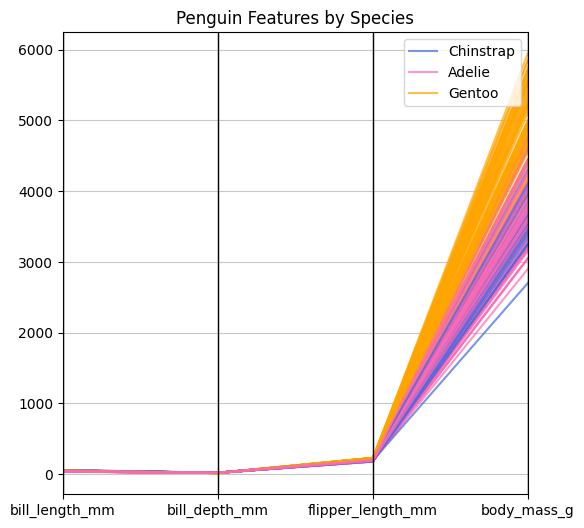

In [3]:
fig = plt.figure(figsize=(6,6))
parallel_coordinates(frame=pen, class_column="species", color=("royalblue", "hotpink", "orange"), alpha=0.7)

plt.title("Penguin Features by Species")
plt.grid(alpha=0.7)
plt.show()

array([[<Axes: xlabel='bill_length_mm', ylabel='bill_length_mm'>,
        <Axes: xlabel='bill_depth_mm', ylabel='bill_length_mm'>,
        <Axes: xlabel='flipper_length_mm', ylabel='bill_length_mm'>,
        <Axes: xlabel='body_mass_g', ylabel='bill_length_mm'>],
       [<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>,
        <Axes: xlabel='bill_depth_mm', ylabel='bill_depth_mm'>,
        <Axes: xlabel='flipper_length_mm', ylabel='bill_depth_mm'>,
        <Axes: xlabel='body_mass_g', ylabel='bill_depth_mm'>],
       [<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>,
        <Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>,
        <Axes: xlabel='flipper_length_mm', ylabel='flipper_length_mm'>,
        <Axes: xlabel='body_mass_g', ylabel='flipper_length_mm'>],
       [<Axes: xlabel='bill_length_mm', ylabel='body_mass_g'>,
        <Axes: xlabel='bill_depth_mm', ylabel='body_mass_g'>,
        <Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>,
        <

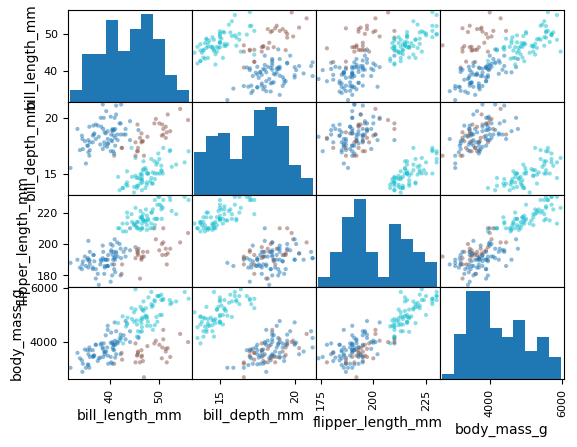

In [4]:
species = pen["species"].to_numpy()

mapping = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
colors = np.vectorize(mapping.get)(species)

pd.plotting.scatter_matrix(
    pen[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]],
    c=colors,
    cmap="tab10"
)


<Figure size 800x800 with 0 Axes>

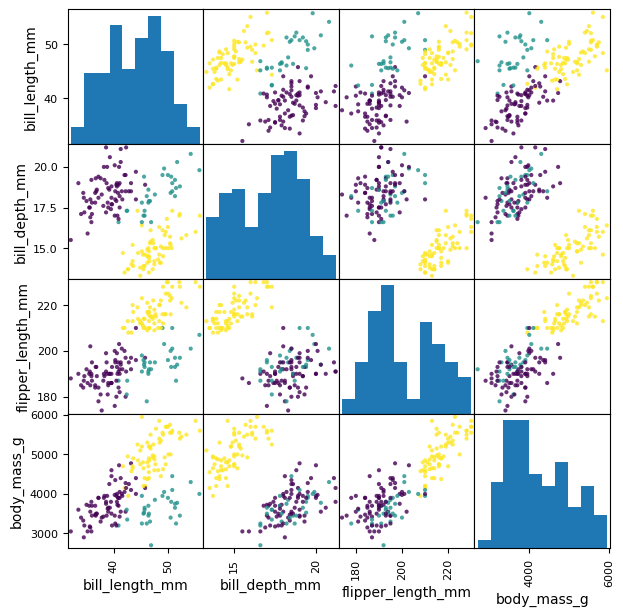

In [5]:
fig = plt.figure(figsize=(8,8))

species = pen["species"].to_numpy()
_, colors = np.unique(species, return_inverse=True)

scatter_matrix(
    pen[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]],
    figsize=(7,7),
    c=colors,
    cmap="viridis",
    alpha=0.8
)

plt.show()

In [6]:
pen = pen.set_index("species")
pen.head(5)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Chinstrap,46.7,17.9,195.0,3300.0
Adelie,35.9,16.6,190.0,3050.0
Adelie,36.6,17.8,185.0,3700.0
Adelie,37.8,18.3,174.0,3400.0
Adelie,35.5,17.5,190.0,3700.0


In [8]:
X = []
species_list = []

for _, row in pen.iterrows():
    temp = []
    length = len(row)
    for i in range(length):
        if i == 0:
            species_list.append(row[i])
        else:
            temp.append(row[i])
        
    X.append(temp)

species_arr = np.array(species_list)
unique_species, species_codes = np.unique(species_arr, return_inverse=True)

leaf_colors = []
for num in species_codes:
    if num == 0:
        leaf_colors.append("royalblue")
    elif num == 1:
        leaf_colors.append("hotpink")
    else:
        leaf_colors.append("orange")

plt.figure(figsize=(12, 12))

dendrogram(
    linkage(X, "ward"),
    labels=species_arr,
    leaf_rotation=90,
    leaf_font_size=10,
    link_color_func=lambda k: leaf_colors[k]  # color leaves by species
)

plt.show()

/tmp/ipykernel_1944892/4037481451.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  species_list.append(row[i])
/tmp/ipykernel_1944892/4037481451.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp.append(row[i])


IndexError: list index out of range

<Figure size 1200x1200 with 0 Axes>